In [1]:
import sys
!{sys.executable} -m pip install -q 'scanpy[leiden]'


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: /n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/bin/python -m pip install --upgrade pip


In [2]:
import scanpy as sc
import scipy as sp
import numpy as np
import matplotlib.pylab as pl
import ot

In [3]:
n_samples = 100

In [155]:
mouse_adata = sc.read_10x_h5('../data/mouse/5k_Mouse_PBMCs_5p_gem-x_5k_Mouse_PBMCs_5p_gem-x_count_sample_filtered_feature_bc_matrix.h5')

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [156]:
# preprocessing mouse
mouse_adata.var_names_make_unique()
sc.pp.filter_cells(mouse_adata, min_genes=100)
sc.pp.filter_genes(mouse_adata, min_cells=3)
mouse_adata.layers["counts"] = mouse_adata.X.copy()
sc.pp.normalize_total(mouse_adata)
sc.pp.log1p(mouse_adata)
sc.pp.highly_variable_genes(mouse_adata, n_top_genes=2000)
sc.tl.pca(mouse_adata)

In [157]:
# labeling cell types on pig
sc.pp.neighbors(mouse_adata)
sc.tl.umap(mouse_adata)

In [158]:
mouse_adata.obs['leiden']=None

In [159]:
sc.tl.leiden(mouse_adata, flavor="igraph", n_iterations=2, resolution=0.1)

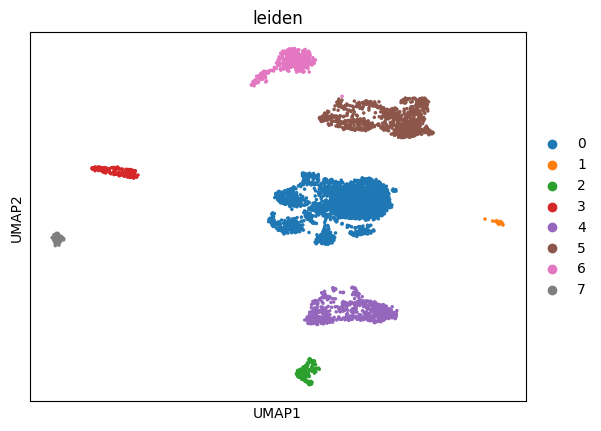

In [160]:
sc.pl.umap(mouse_adata, color=["leiden"])

In [161]:
mouse_marker_genes = {
    "T": ["Cd4", "Cd8a", "Ccr7", "Sell", "Cd3e", "Id2", "Cd44", "Klrb1c", "Gzma"],
    "NK": ["Nkg7"],
    "B": ["Ms4a1","Cd79a"],
    "Mono/DC": ["Cx3cr1", "Ly6c2", "Ccr2", "Csf1r", "Cd209a", "Syngr2"],
    "Megakaryocytes": ["Ppbp", "Pf4", "Gng11"],
    "Macrophages": ["C1qa", "C1qb", "C1qc"],
    "Basophil": ["Fcer1a", "Cd200r3", "Ms4a2"],
    "RBC": ['Hba-a1'],
    "Neutrophil": ["Csf3r","Cxcr2","Ncf4"]
}

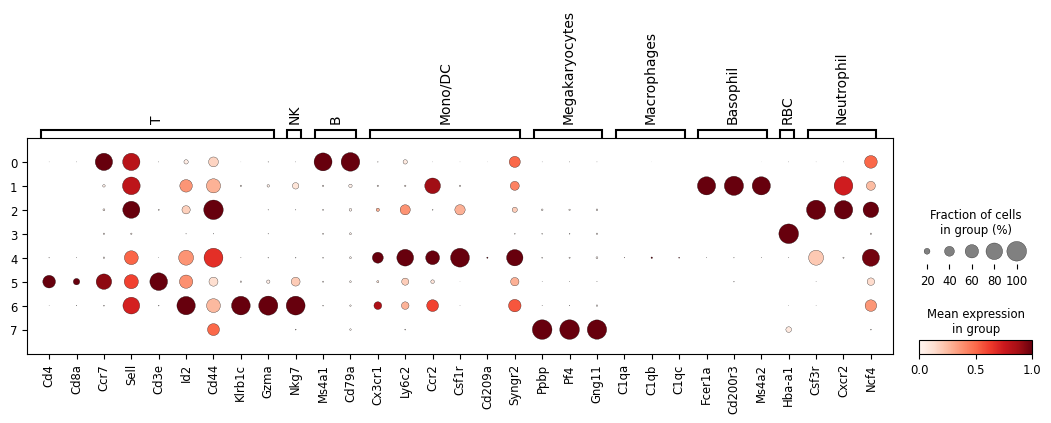

In [162]:
sc.pl.dotplot(mouse_adata, mouse_marker_genes, groupby="leiden", standard_scale="var")

In [163]:
mouse_leiden_cell_types = {"0":"B",
                           "1":"Basophil",
                           "2":"Neutrophil",
                           "3":"Erythrocyte",
                           "4":"Monocyte/DC",
                           "5":"T/NK",
                           "6":"T/NK",
                           "7":"Megakaryocyte"
                          }

In [164]:
mouse_cell_type_labels = [mouse_leiden_cell_types[cluster] for cluster in mouse_adata.obs['leiden']]

In [165]:
mouse_adata.obs['cell_types'] = mouse_cell_type_labels

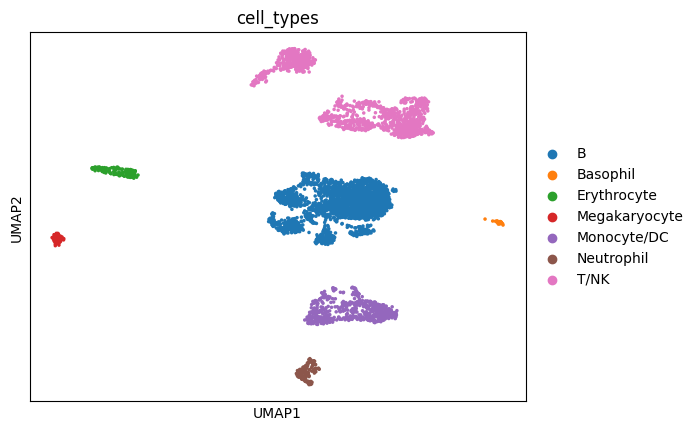

In [166]:
sc.pl.umap(mouse_adata, color=["cell_types"])

In [167]:
mouse_small = sc.pp.subsample(mouse_adata, n_obs=n_samples, copy=True)

In [129]:
human_adata = sc.read_10x_h5('../data/human/pbmc_10k_v3_raw_feature_bc_matrix.h5')

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [130]:
# preprocessing human
human_adata.var_names_make_unique()
sc.pp.filter_cells(human_adata, min_genes=100)
sc.pp.filter_genes(human_adata, min_cells=3)
human_adata.layers["counts"] = human_adata.X.copy()
sc.pp.normalize_total(human_adata)
sc.pp.log1p(human_adata)
sc.pp.highly_variable_genes(human_adata, n_top_genes=2000)
sc.tl.pca(human_adata)

In [131]:
# labeling cell types on human
sc.pp.neighbors(human_adata)
sc.tl.umap(human_adata)

In [132]:
sc.tl.leiden(human_adata, flavor="igraph", n_iterations=2, resolution=0.2)

In [133]:
human_adata

AnnData object with n_obs × n_vars = 14264 × 20311
    obs: 'n_genes', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

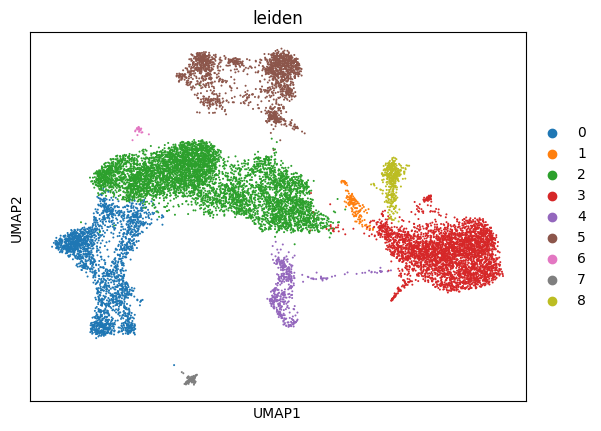

In [134]:
sc.pl.umap(human_adata, color=["leiden"])

In [135]:
human_marker_genes = {
    "Mono/DC": ["FCN1", "CD14", "TCF7L2", "FCGR3A", "LYN", "CST3", "COTL1", "LYZ", "DMXL2", "CLEC10A", "FCER1A",
               "GZMB", "IL3RA", "COBLL1", "TCF4"],
    "NK": ["GNLY", "NKG7", "CD247", "FCER1G", "TYROBP", "KLRG1", "FCGR3A", "IL2RA","NCAM1"],
    "B cells": [
        "MS4A1",
        "ITGB1",
        "COL4A4",
        "PRDM1",
        "IRF4",
        "PAX5",
        "BCL11A",
        "BLK",
        "IGHD",
        "IGHM","MZB1", "HSP90B1", "FNDC3B", "PRDM1", "IGKC", "JCHAIN"],
    "T": ["CD4", "IL7R", "TRBC2", "CD8A", "CD8B", "GZMK", "GZMA", "CCL5", "GZMB", "GZMH", "GZMA"],
    "Neutrophil": ["CSF3R","CXCR2","NCF4","CD33"],
    "RBC": ['HBA1'],
    "Basophil": ["FCER1A", "MS4A2"],
    "Megakaryocytes": ["PPBP", "PF4", "GNG11"],
    "Platelets": ["ITGA2B"]
}

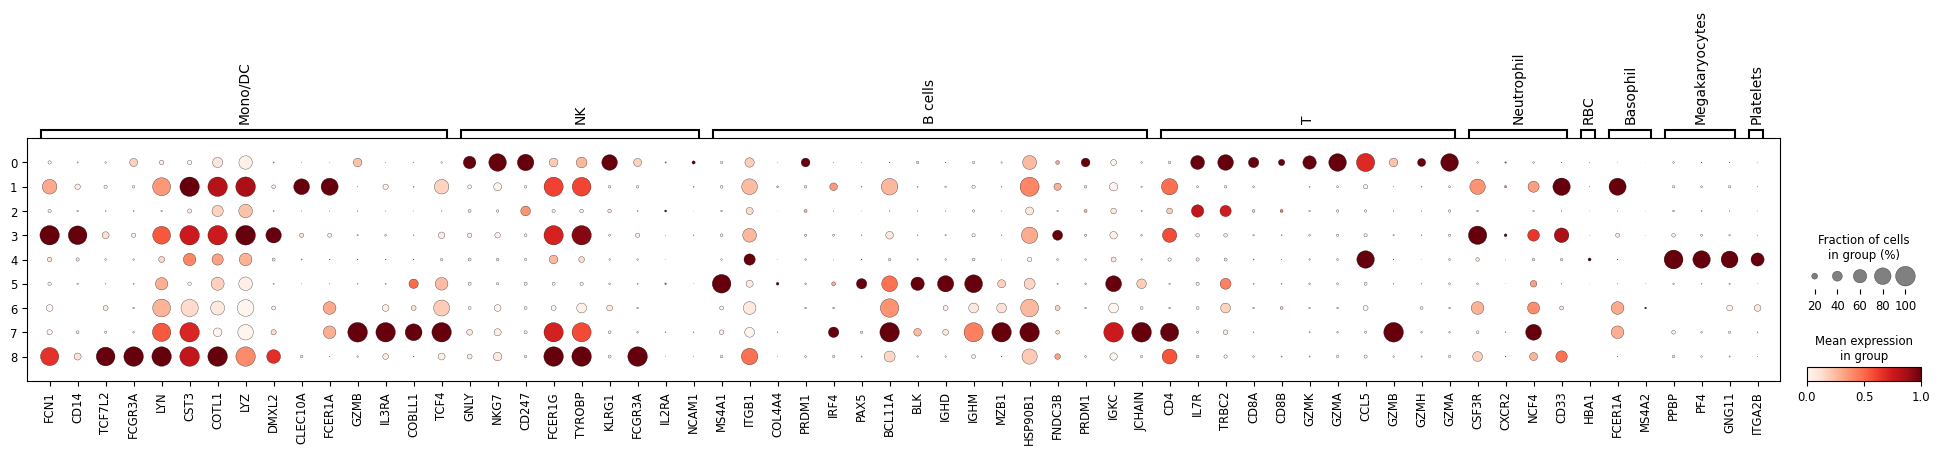

In [136]:
sc.pl.dotplot(human_adata, human_marker_genes, groupby="leiden", standard_scale="var")

In [149]:
human_leiden_cell_types = {"0":"T/NK",
                           "1":"Monocyte/DC",
                           "2":"T/NK",
                           "3":"Monocyte/DC",
                           "4":"Megakaryocyte",
                           "5":"B",
                           "6":"Multipotent Progenitor",
                           "7":"pDC",
                           "8":"Macrophage"
                          }

In [150]:
sc.tl.rank_genes_groups(human_adata, groupby="leiden", method="wilcoxon")
sc.get.rank_genes_groups_df(human_adata, group="8").head(5)

,names,scores,logfoldchanges,pvals,pvals_adj
0,FCGR3A,33.073536,6.467412,7.138746e-240,1.449951e-235
1,LST1,32.439281,4.410693,7.671608e-231,7.790901e-227
2,SMIM25,32.258480,5.042325,2.675332e-228,1.811289e-224
3,AIF1,31.391014,4.022476,2.683625e-216,1.362677e-212
4,MS4A7,31.142630,4.499273,6.382510e-213,2.592703e-209


In [168]:
human_cell_type_labels = [human_leiden_cell_types[cluster] for cluster in human_adata.obs['leiden']]

In [169]:
human_adata.obs['cell_types'] = human_cell_type_labels

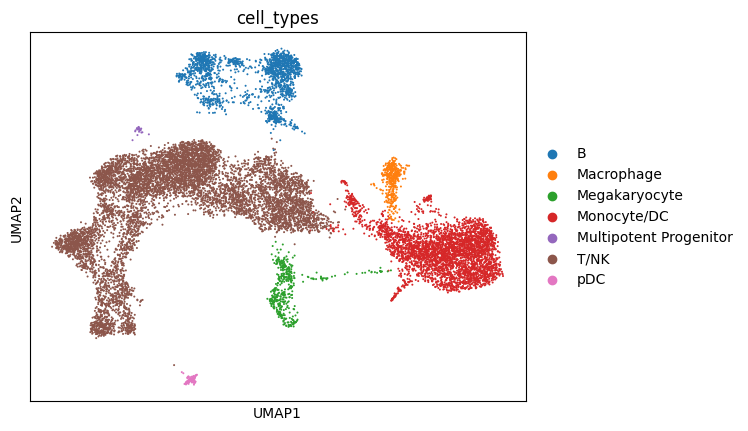

In [170]:
sc.pl.umap(human_adata, color=["cell_types"])

In [171]:
human_small = sc.pp.subsample(human_adata, n_obs=n_samples, copy=True)

# Now run OT with 10 dims

In [173]:
xs = mouse_small.obsm['X_pca']
xt = human_small.obsm['X_pca']

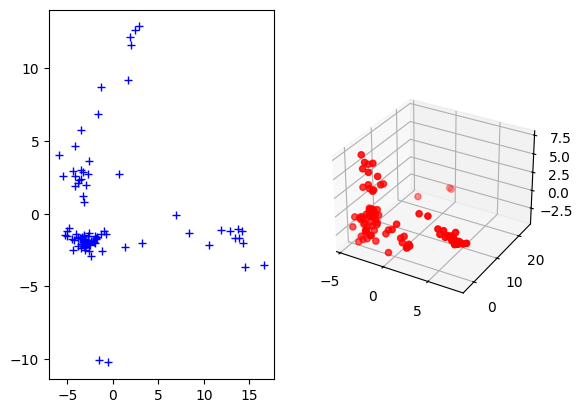

In [174]:
fig = pl.figure(1)
ax1 = fig.add_subplot(121)
ax1.plot(xs[:, 0], xs[:, 1], "+b", label="Source samples")
ax2 = fig.add_subplot(122, projection="3d")
ax2.scatter(xt[:, 0], xt[:, 1], xt[:, 2], color="r")
pl.show()

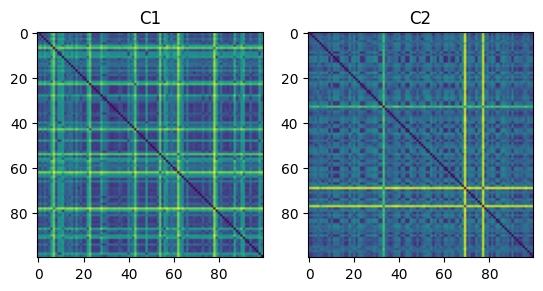

In [175]:
C1 = sp.spatial.distance.cdist(xs, xs)
C2 = sp.spatial.distance.cdist(xt, xt)

C1 /= C1.max()
C2 /= C2.max()

pl.figure(2)
pl.subplot(121)
pl.imshow(C1)
pl.title("C1")

pl.subplot(122)
pl.imshow(C2)
pl.title("C2")

pl.show()

It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|6.206054e-02|0.000000e+00|0.000000e+00
    1|2.299049e-02|1.699400e+00|3.907005e-02
    2|2.299049e-02|0.000000e+00|0.000000e+00
It.  |Err         
-------------------
    0|2.730434e-02|


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


   10|6.986871e-03|
   20|6.129270e-04|
   30|2.121303e-04|
   40|4.816870e-05|
   50|2.438909e-05|
   60|3.260193e-05|
   70|1.008845e-05|
   80|2.890783e-05|
   90|1.459600e-04|
  100|4.005896e-05|
  110|6.300465e-05|
  120|5.079148e-04|
  130|1.115917e-04|
  140|1.426331e-06|
  150|1.974103e-05|
  160|1.257621e-06|
  170|1.849968e-08|
  180|4.502570e-09|
  190|9.200232e-09|
It.  |Err         
-------------------
  200|4.055260e-08|
  210|6.840418e-08|
  220|7.748775e-08|
  230|7.655846e-08|
  240|7.683245e-08|
  250|1.232906e-07|
  260|4.198050e-07|
  270|3.123468e-06|
  280|6.433925e-05|
  290|7.608237e-05|
  300|6.161641e-07|
  310|8.124364e-07|
  320|5.326523e-07|
  330|2.040320e-07|
  340|5.892234e-08|
  350|1.624127e-08|
  360|4.817730e-09|
  370|1.517006e-09|
  380|4.954116e-10|
It.  |Err         
-------------------
    0|2.730434e-02|
   10|7.621754e-03|
   20|1.928535e-03|
   30|8.980234e-05|
   40|1.034434e-05|
   50|1.499984e-06|
   60|2.318207e-07|
   70|3.905776e-08|
  

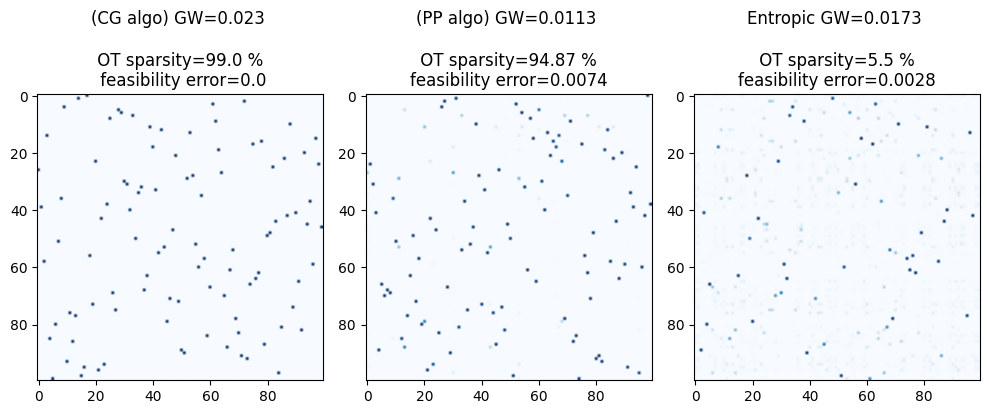

In [176]:
p = ot.unif(n_samples)
q = ot.unif(n_samples)

# Conditional Gradient algorithm
gw0, log0 = ot.gromov.gromov_wasserstein(
    C1, C2, p, q, "square_loss", verbose=True, log=True
)

# Proximal Point algorithm with Kullback-Leibler as proximal operator
gw, log = ot.gromov.entropic_gromov_wasserstein(
    C1, C2, p, q, "square_loss", epsilon=5e-4, solver="PPA", log=True, verbose=True
)

# Projected Gradient algorithm with entropic regularization
gwe, loge = ot.gromov.entropic_gromov_wasserstein(
    C1, C2, p, q, "square_loss", epsilon=5e-4, solver="PGD", log=True, verbose=True
)

print(
    "Gromov-Wasserstein distance estimated with Conditional Gradient solver: "
    + str(log0["gw_dist"])
)
print(
    "Gromov-Wasserstein distance estimated with Proximal Point solver: "
    + str(log["gw_dist"])
)
print(
    "Entropic Gromov-Wasserstein distance estimated with Projected Gradient solver: "
    + str(loge["gw_dist"])
)

# compute OT sparsity level
gw0_sparsity = 100 * (gw0 == 0.0).astype(np.float64).sum() / (n_samples**2)
gw_sparsity = 100 * (gw == 0.0).astype(np.float64).sum() / (n_samples**2)
gwe_sparsity = 100 * (gwe == 0.0).astype(np.float64).sum() / (n_samples**2)

# Methods using Sinkhorn projections tend to produce feasibility errors on the
# marginal constraints

err0 = np.linalg.norm(gw0.sum(1) - p) + np.linalg.norm(gw0.sum(0) - q)
err = np.linalg.norm(gw.sum(1) - p) + np.linalg.norm(gw.sum(0) - q)
erre = np.linalg.norm(gwe.sum(1) - p) + np.linalg.norm(gwe.sum(0) - q)

pl.figure(3, (10, 6))
cmap = "Blues"
fontsize = 12
pl.subplot(131)
pl.imshow(gw0, cmap=cmap)
pl.title(
    "(CG algo) GW=%s \n  \n OT sparsity=%s \n feasibility error=%s"
    % (
        np.round(log0["gw_dist"], 4),
        str(np.round(gw0_sparsity, 2)) + " %",
        np.round(np.round(err0, 4)),
    ),
    fontsize=fontsize,
)

pl.subplot(132)
pl.imshow(gw, cmap=cmap)
pl.title(
    "(PP algo) GW=%s \n  \n OT sparsity=%s \nfeasibility error=%s"
    % (
        np.round(log["gw_dist"], 4),
        str(np.round(gw_sparsity, 2)) + " %",
        np.round(err, 4),
    ),
    fontsize=fontsize,
)

pl.subplot(133)
pl.imshow(gwe, cmap=cmap)
pl.title(
    "Entropic GW=%s \n  \n OT sparsity=%s \nfeasibility error=%s"
    % (
        np.round(loge["gw_dist"], 4),
        str(np.round(gwe_sparsity, 2)) + " %",
        np.round(erre, 4),
    ),
    fontsize=fontsize,
)

pl.tight_layout()
pl.show()

In [177]:
np.sum(gw)

np.float64(1.0)

### Next steps
1. Identify predicted human cell for each pig cell
2. Label cell types
3. Visualize / quantify whether cell types were correctly paired
4. Repeat with two mice and two humans

In [178]:
# identify predicted human cell for each pig cell
argmax_arr = np.argmax(gw, axis=1) # row sum

In [191]:
cell_pairs = []
cell_type_pairs = []
for col in range(len(argmax_arr)):
    mouse_cell_num = col
    human_cell_num = int(argmax_arr[col])
    cell_pairs.append((mouse_cell_num, human_cell_num))
    cell_type_pairs.append((mouse_small.obs['cell_types'][mouse_cell_num], human_small.obs['cell_types'][human_cell_num]))

/tmp/ipykernel_86325/426209540.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cell_type_pairs.append((mouse_small.obs['cell_types'][mouse_cell_num], human_small.obs['cell_types'][human_cell_num]))


In [192]:
cell_type_pairs

[('B', 'T/NK'),
 ('B', 'Monocyte/DC'),
 ('B', 'T/NK'),
 ('B', 'Monocyte/DC'),
 ('B', 'T/NK'),
 ('T/NK', 'Monocyte/DC'),
 ('Monocyte/DC', 'T/NK'),
 ('Megakaryocyte', 'Megakaryocyte'),
 ('B', 'Monocyte/DC'),
 ('T/NK', 'T/NK'),
 ('T/NK', 'T/NK'),
 ('Monocyte/DC', 'T/NK'),
 ('T/NK', 'Monocyte/DC'),
 ('B', 'Monocyte/DC'),
 ('T/NK', 'Monocyte/DC'),
 ('B', 'T/NK'),
 ('B', 'T/NK'),
 ('B', 'T/NK'),
 ('B', 'B'),
 ('T/NK', 'Monocyte/DC'),
 ('B', 'T/NK'),
 ('B', 'Monocyte/DC'),
 ('Monocyte/DC', 'T/NK'),
 ('Erythrocyte', 'T/NK'),
 ('B', 'T/NK'),
 ('B', 'T/NK'),
 ('B', 'T/NK'),
 ('B', 'T/NK'),
 ('T/NK', 'T/NK'),
 ('T/NK', 'Monocyte/DC'),
 ('T/NK', 'Monocyte/DC'),
 ('B', 'T/NK'),
 ('B', 'T/NK'),
 ('B', 'T/NK'),
 ('B', 'B'),
 ('B', 'T/NK'),
 ('T/NK', 'Monocyte/DC'),
 ('B', 'Monocyte/DC'),
 ('B', 'T/NK'),
 ('B', 'T/NK'),
 ('T/NK', 'T/NK'),
 ('B', 'B'),
 ('Monocyte/DC', 'T/NK'),
 ('Erythrocyte', 'T/NK'),
 ('B', 'B'),
 ('B', 'T/NK'),
 ('B', 'T/NK'),
 ('B', 'Monocyte/DC'),
 ('T/NK', 'T/NK'),
 ('B', 'T/NK'

In [181]:
mouse_small.obs.head(10)

,n_genes,leiden,cell_types
AATGTCAGTAACTTCT-1,3070,0,B
ATCACATAGAGCATGG-1,1828,0,B
AGTCTGGGTGTCTAGG-1,4326,0,B
AAGTGTCGTATGTTGA-1,899,0,B
GCCTGCTTCCCCACTA-1,5306,0,B
ACTGTTGAGCAGCGTT-1,2691,5,T/NK
ATTCGCTTCATACAAC-1,5585,4,Monocyte/DC
GGACCGACAGTGGCAG-1,338,7,Megakaryocyte
GCTACAGGTATCCGTC-1,2774,0,B
ATTGAGAAGCGTTACA-1,3264,6,T/NK


In [35]:
human_small.obs.iloc[81,:]

n_genes    1136
leiden        6
Name: TCGATTTCACAAGCCC-1, dtype: object

pig 7 (naive T) -> human 0 (naive T) 
pig 1 (NK) -> human 8 (NK)
pig 2 (unclear) -> human 6 (myeloid)
pig 2 (unclear) -> human 
pig 7 (naive T) -> human 0 (naive T)
pig 0 (naive T) -> human 14 (cDC2)
pig 17 (NK) -> human 8 (NK)

In [36]:
np.array([[0, 1], [0, 5]])

array([[0, 1],
       [0, 5]])

In [37]:
np.sum(np.array([[0, 1], [0, 5]]),axis=1)

array([1, 5])

In [186]:
cell_pairs[:5]

[(0, 98), (1, 31), (2, 27), (3, 52), (4, 26)]

In [187]:
mouse_small.obs.head(5)

,n_genes,leiden,cell_types
AATGTCAGTAACTTCT-1,3070,0,B
ATCACATAGAGCATGG-1,1828,0,B
AGTCTGGGTGTCTAGG-1,4326,0,B
AAGTGTCGTATGTTGA-1,899,0,B
GCCTGCTTCCCCACTA-1,5306,0,B


In [189]:
human_small.obs.iloc[98]

n_genes       1476
leiden           2
cell_types    T/NK
Name: GTCACTCTCATTATCC-1, dtype: object